# Oportunidades de venta cruzada (Market Basket Analysis)
## Pregunta de negocio: donde esta la mayor oportunidad de venta cruzada?

Detectamos que productos se compran juntos (soporte, confianza, lift) para priorizar bundles y promociones.

**Autor:** Pablo Morales | **Datos:** sinteticos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", None)

## 1. Cargar transacciones

In [2]:
df = pd.read_csv("data/transacciones.csv", parse_dates=["fecha"])
print(f"Lineas: {len(df):,} | Boletas: {df.boleta_id.nunique():,}")
df.head()

Lineas: 14,572 | Boletas: 5,000


,boleta_id,fecha,tienda,producto,categoria,cantidad,precio_unit,monto
0,1,2026-08-10,Tienda Centro,Agua mineral,Bebidas,1,900,900
1,2,2026-06-07,Tienda Centro,Azúcar,Café/Té,1,1300,1300
2,2,2026-06-07,Tienda Centro,Cerveza,Alcohol,1,3500,3500
3,2,2026-06-07,Tienda Centro,Croissant,Panadería,1,900,900
4,2,2026-06-07,Tienda Centro,Pañales,Bebé,1,8000,8000


## 2. Ventas por categoria y producto

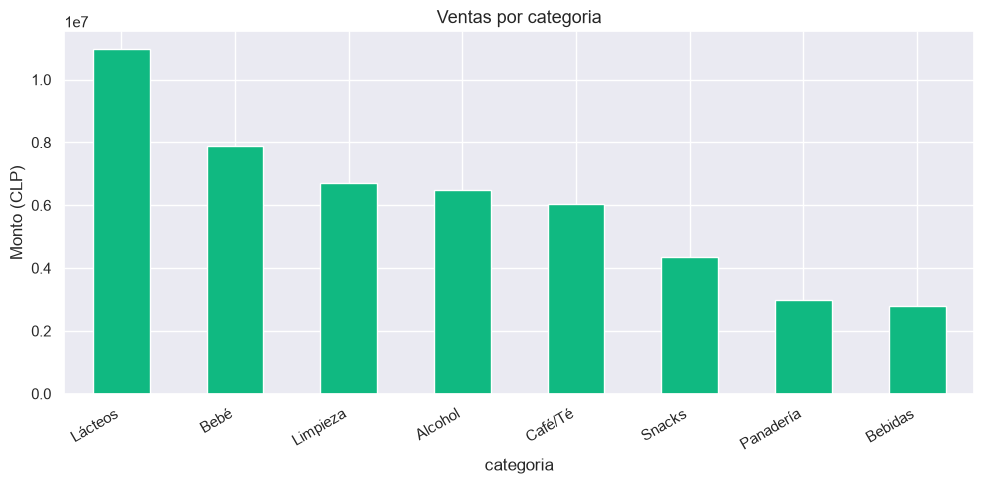

In [3]:
cat = df.groupby("categoria")["monto"].sum().sort_values(ascending=False)
ax = cat.plot(kind="bar", color="#10b981")
ax.set_title("Ventas por categoria"); ax.set_ylabel("Monto (CLP)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 3. Market basket: soporte, confianza y lift
Para cada par de productos calculamos:
- **soporte** = P(A y B)
- **confianza(A->B)** = P(B | A)
- **lift** = soporte / (P(A)*P(B)). lift > 1 = afinidad real.

In [4]:
from itertools import combinations
from collections import Counter

cestas = df.groupby("boleta_id")["producto"].apply(set)
n = len(cestas)
sing = Counter()
par = Counter()
for items in cestas:
    for p in items:
        sing[p] += 1
    for a, b in combinations(sorted(items), 2):
        par[(a, b)] += 1

filas = []
for (a, b), c in par.items():
    sop = c / n
    if sop < 0.01:
        continue
    conf = c / sing[a]
    lift = sop / ((sing[a]/n) * (sing[b]/n))
    filas.append({"par": f"{a} + {b}", "soporte": round(sop,4),
                  "confianza": round(conf,3), "lift": round(lift,2), "boletas": c})
reglas = pd.DataFrame(filas).sort_values("lift", ascending=False)
reglas.head(10)

,par,soporte,confianza,lift,boletas
7,Pañales + Toallitas húmedas,0.0734,0.741,4.64,367
36,Azúcar + Café,0.0666,0.327,3.44,333
12,Cloro + Detergente,0.0516,0.348,3.22,258
14,Detergente + Esponjas,0.0436,0.404,2.99,218
125,Mantequilla + Pan molde,0.0612,0.311,2.98,306
56,Azúcar + Té,0.0576,0.283,2.96,288
52,Mantequilla + Pan hallulla,0.0576,0.293,2.86,288
31,Café + Galletas,0.0340,0.357,2.83,170
18,Cerveza + Maní,0.0520,0.426,2.80,260
8,Cerveza + Papas fritas,0.0610,0.499,2.80,305


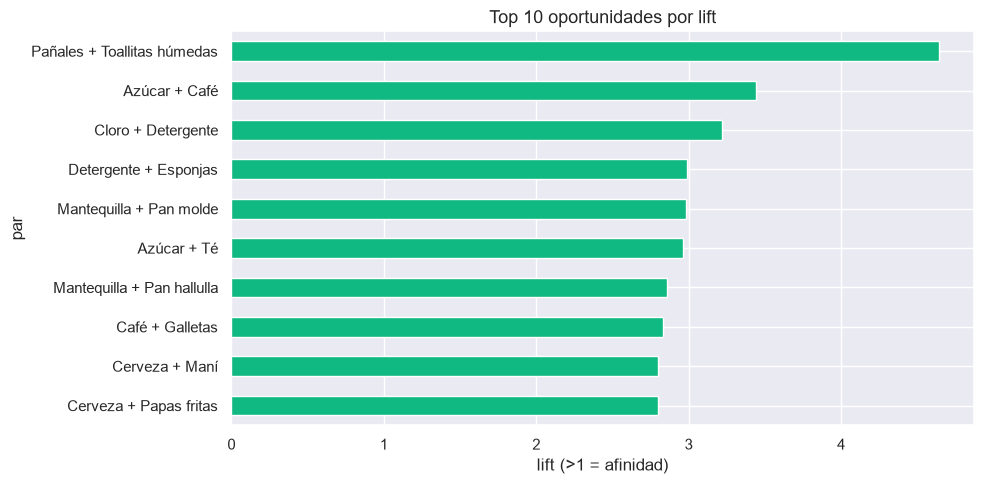

In [5]:
top = reglas.head(10).sort_values("lift")
ax = top.set_index("par")["lift"].plot(kind="barh", color="#10b981")
ax.set_title("Top 10 oportunidades por lift"); ax.set_xlabel("lift (>1 = afinidad)")
plt.tight_layout(); plt.show()

## 4. Conclusiones de negocio

- La combinacion con mayor lift es la oportunidad mas fuerte para un **bundle** o promo cruzada.
- Pares con alto lift y buena confianza son candidatos a **ubicacion conjunta en gondola** y recomendaciones en e-commerce.
- **Accion recomendada:** disenar promociones sobre los 3-5 pares de mayor lift y medir el efecto en ticket promedio.